In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile

zip_file_path = '/content/drive/My Drive/archive.zip'
extract_folder_path = '/content/BrainTumour_Dataset/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder_path)

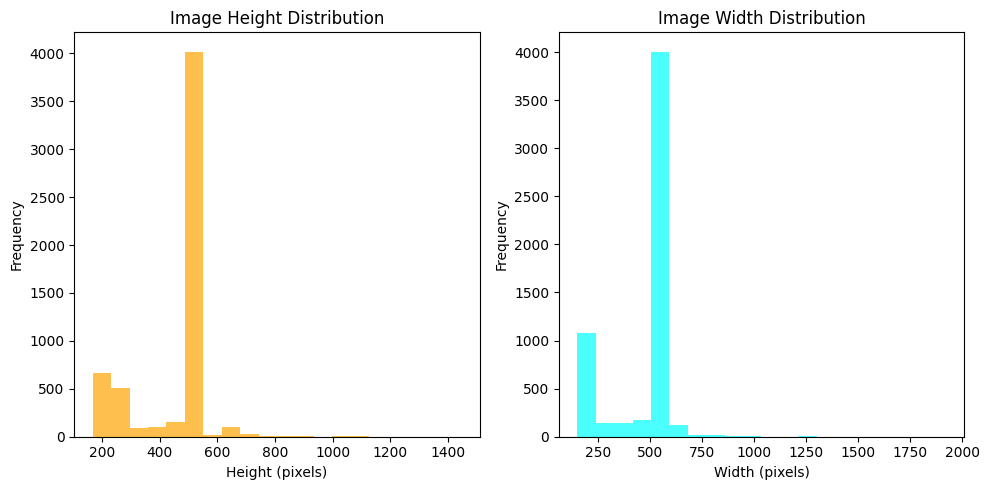

In [4]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# Update this path to where the dataset was unzipped
data_dir = '/content/BrainTumour_Dataset/Training/'
categories = ['glioma', 'meningioma', 'notumor', 'pituitary']
# Image Size Distribution
def plot_image_size_distribution(data_dir, categories):
    image_sizes = []
    for category in categories:
        category_path = os.path.join(data_dir, category)
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image_sizes.append(img.shape)

    image_sizes = np.array(image_sizes)
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.hist(image_sizes[:, 0], bins=20, color='orange', alpha=0.7)
    plt.title("Image Height Distribution")
    plt.xlabel("Height (pixels)")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    plt.hist(image_sizes[:, 1], bins=20, color='cyan', alpha=0.7)
    plt.title("Image Width Distribution")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

plot_image_size_distribution(data_dir, categories)

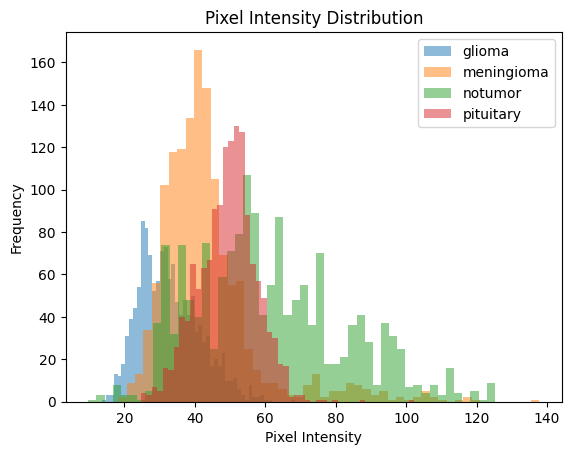

In [5]:
import numpy as np
for category in categories:
    image_path = os.path.join(data_dir, category)
    images = [cv2.imread(os.path.join(image_path, img), 0) for img in os.listdir(image_path)]
    pixel_values = [np.mean(img) for img in images]
    plt.hist(pixel_values, bins=50, alpha=0.5, label=category)

plt.legend()
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

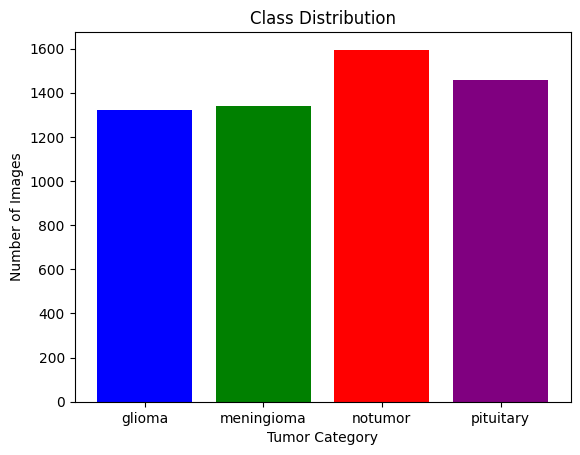

In [6]:


# Class Distribution
def plot_class_distribution(data_dir, categories):
    class_counts = {}
    for category in categories:
        class_counts[category] = len(os.listdir(os.path.join(data_dir, category)))

    plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'green', 'red', 'purple'])
    plt.title("Class Distribution")
    plt.xlabel("Tumor Category")
    plt.ylabel("Number of Images")
    plt.show()

plot_class_distribution(data_dir, categories)


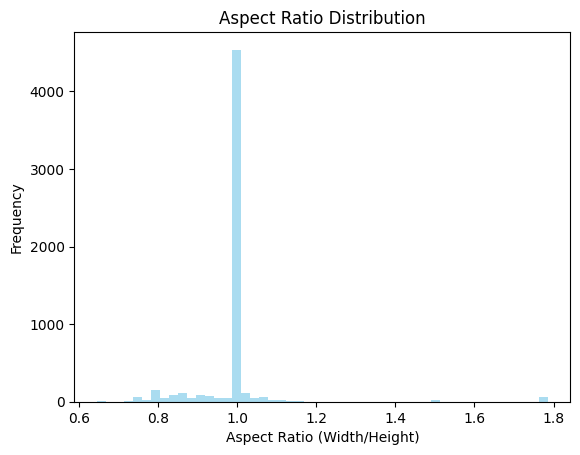

In [7]:
def analyze_aspect_ratio(data_dir, categories):
    aspect_ratios = []
    for category in categories:
        category_path = os.path.join(data_dir, category)
        img_list = os.listdir(category_path)

        for img_name in img_list:
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                aspect_ratio = img.shape[1] / img.shape[0]
                aspect_ratios.append(aspect_ratio)

    plt.hist(aspect_ratios, bins=50, color='skyblue', alpha=0.7)
    plt.title("Aspect Ratio Distribution")
    plt.xlabel("Aspect Ratio (Width/Height)")
    plt.ylabel("Frequency")
    plt.show()

analyze_aspect_ratio(data_dir, categories)

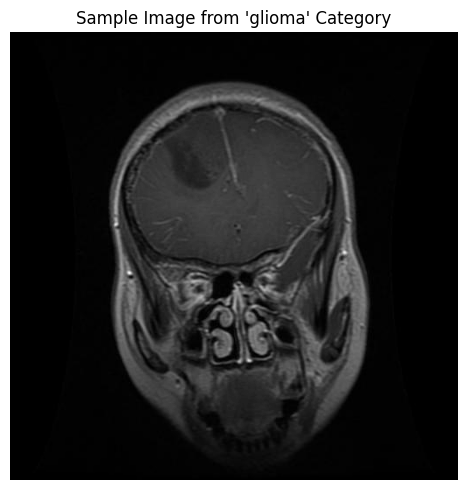

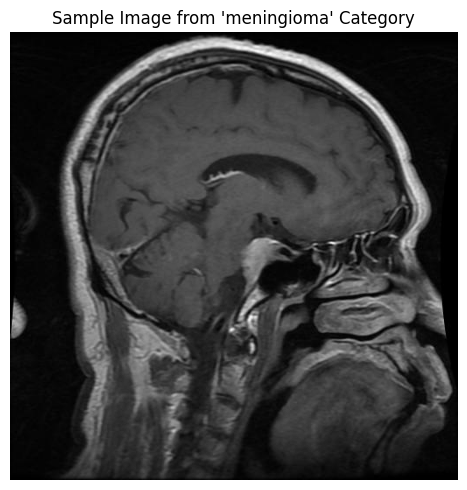

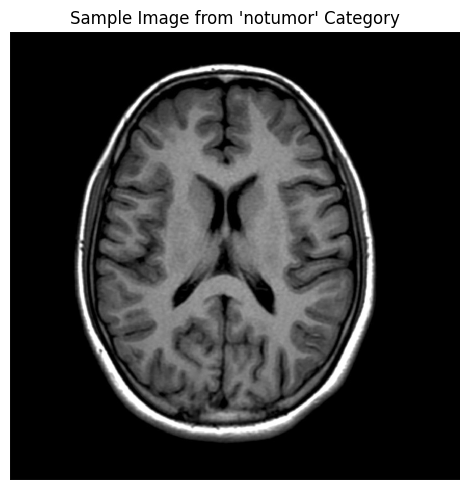

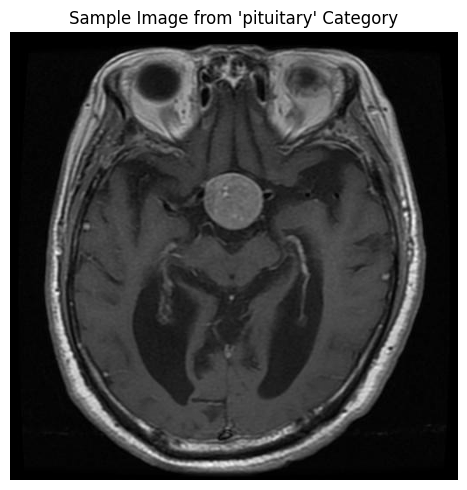

In [8]:
def load_sample_image(data_dir, category):
    category_path = os.path.join(data_dir, category)
    sample_image_name = os.listdir(category_path)[0]  # Load the first image in the folder
    sample_image_path = os.path.join(category_path, sample_image_name)
    sample_image = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
    return sample_image

# Visualize the image and its pixel intensity distribution
def visualize_image(image, category_name):
    # Plot the image
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Sample Image from '{category_name}' Category")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Load and visualize a sample image from one category
for category in categories:  # Choose a category to visualize
    sample_image = load_sample_image(data_dir, category)
    visualize_image(sample_image, category)

In [9]:
import hashlib

def dhash(image, hash_size=8):
    resized = cv2.resize(image, (hash_size + 1, hash_size))
    diff = resized[:, 1:] > resized[:, :-1]
    return sum([2 ** i for (i, v) in enumerate(diff.flatten()) if v])

def remove_duplicates(data_dir):
    image_hashes = {}
    duplicates = []

    for category in os.listdir(data_dir):
        category_path = os.path.join(data_dir, category)

        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img_hash = dhash(img)

            if img_hash in image_hashes:
                print(f"Duplicate found: {img_name} is a duplicate of {image_hashes[img_hash]}")
                duplicates.append(img_path)
            else:
                image_hashes[img_hash] = img_name

    for duplicate in duplicates:
        os.remove(duplicate)
        print(f"Deleted duplicate image: {duplicate}")

remove_duplicates(data_dir)

Duplicate found: Tr-no_0799.jpg is a duplicate of Tr-no_1475.jpg
Duplicate found: Tr-no_1126.jpg is a duplicate of Tr-no_0225.jpg
Duplicate found: Tr-no_0091.jpg is a duplicate of Tr-no_0345.jpg
Duplicate found: Tr-no_0020.jpg is a duplicate of Tr-no_1006.jpg
Duplicate found: Tr-no_0057.jpg is a duplicate of Tr-no_0984.jpg
Duplicate found: Tr-no_1138.jpg is a duplicate of Tr-no_0178.jpg
Duplicate found: Tr-no_0027.jpg is a duplicate of Tr-no_1193.jpg
Duplicate found: Tr-no_0298.jpg is a duplicate of Tr-no_0231.jpg
Duplicate found: Tr-no_1563.jpg is a duplicate of Tr-no_1204.jpg
Duplicate found: Tr-no_1091.jpg is a duplicate of Tr-no_0054.jpg
Duplicate found: Tr-no_0190.jpg is a duplicate of Tr-no_0962.jpg
Duplicate found: Tr-no_1223.jpg is a duplicate of Tr-no_0531.jpg
Duplicate found: Tr-no_1069.jpg is a duplicate of Tr-no_1193.jpg
Duplicate found: Tr-no_0324.jpg is a duplicate of Tr-no_0984.jpg
Duplicate found: Tr-no_1572.jpg is a duplicate of Tr-no_1507.jpg
Duplicate found: Tr-no_11

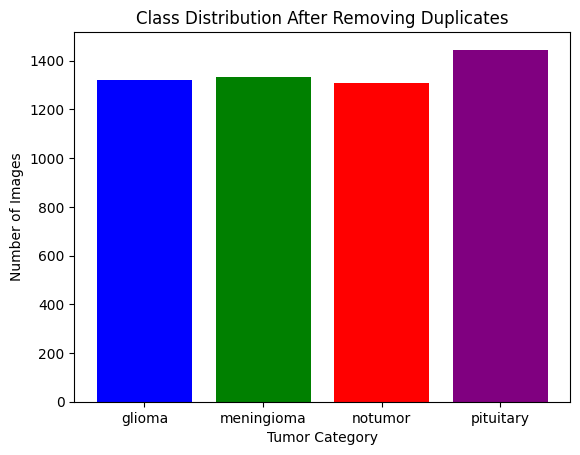

In [10]:
def plot_class_distribution(data_dir, categories):
    class_counts = {}
    for category in categories:
        class_counts[category] = len(os.listdir(os.path.join(data_dir, category)))

    plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'green', 'red', 'purple'])
    plt.title("Class Distribution After Removing Duplicates")
    plt.xlabel("Tumor Category")
    plt.ylabel("Number of Images")
    plt.show()

plot_class_distribution(data_dir, categories)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Define image size and other parameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

# Paths
train_dir = '/content/BrainTumour_Dataset/Training/'
# If you have a separate validation directory, define it here. Otherwise, we'll split the training data.
# val_dir = '/content/BrainTumour_Dataset/Validation/'


In [14]:
# ImageDataGenerator for training with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values
    rotation_range=30,           # Rotate images by 30 degrees
    width_shift_range=0.2,       # Horizontal shift
    height_shift_range=0.2,      # Vertical shift
    shear_range=0.2,             # Shear transformation
    zoom_range=0.2,              # Zoom in/out
    horizontal_flip=True,        # Randomly flip images
    fill_mode='nearest',         # Fill missing pixels
    validation_split=0.2          # Split 20% of data for validation
)

# ImageDataGenerator for validation (only rescaling)
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',            # Set as training data
    shuffle=True,
    seed=42
)

# Create validation generator
validation_generator = validation_datagen.flow_from_directory(
    train_dir,                    # Same directory as training data
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',          # Set as validation data
    shuffle=True,
    seed=42
)


Found 4326 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.


In [18]:
def build_basic_cnn(input_shape=(224, 224, 1), num_classes=4):
    model = Sequential()

    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Second Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Third Convolutional Block
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Flatten and Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))  # To prevent overfitting
    model.add(Dense(num_classes, activation='softmax'))

    return model

# Since the images are grayscale, set input_shape accordingly
input_shape = (IMG_SIZE, IMG_SIZE, 3)  # Grayscale
model = build_basic_cnn(input_shape=input_shape, num_classes=4)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [20]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


135/135 ━━━━━━━━━━━━━━━━━━━━ 76s 469ms/step - accuracy: 0.4170 - loss: 4.9232 - val_accuracy: 0.2670 - val_loss: 12.5462
Epoch 2/20
  1/135 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.4375 - loss: 1.0698

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.4375 - loss: 1.0698 - val_accuracy: 0.2917 - val_loss: 8.3708
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 61s 436ms/step - accuracy: 0.4512 - loss: 1.2557 - val_accuracy: 0.2661 - val_loss: 3.3189
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3438 - loss: 1.5099 - val_accuracy: 0.3750 - val_loss: 3.9018
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 79s 421ms/step - accuracy: 0.4948 - loss: 1.1920 - val_accuracy: 0.4081 - val_loss: 1.6423
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4688 - loss: 2.0614 - val_accuracy: 0.5000 - val_loss: 1.0924
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 59s 420ms/step - accuracy: 0.4796 - loss: 1.2089 - val_accuracy: 0.5256 - val_loss: 1.8335
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 241us/step - accuracy: 0.4688 - loss: 1.0340 - val_accuracy: 0.5000 - val_loss: 1.3280
Epoch 9/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 84s 435ms/step - accuracy: 0.5221 - loss: 1.0974 - val_accuracy

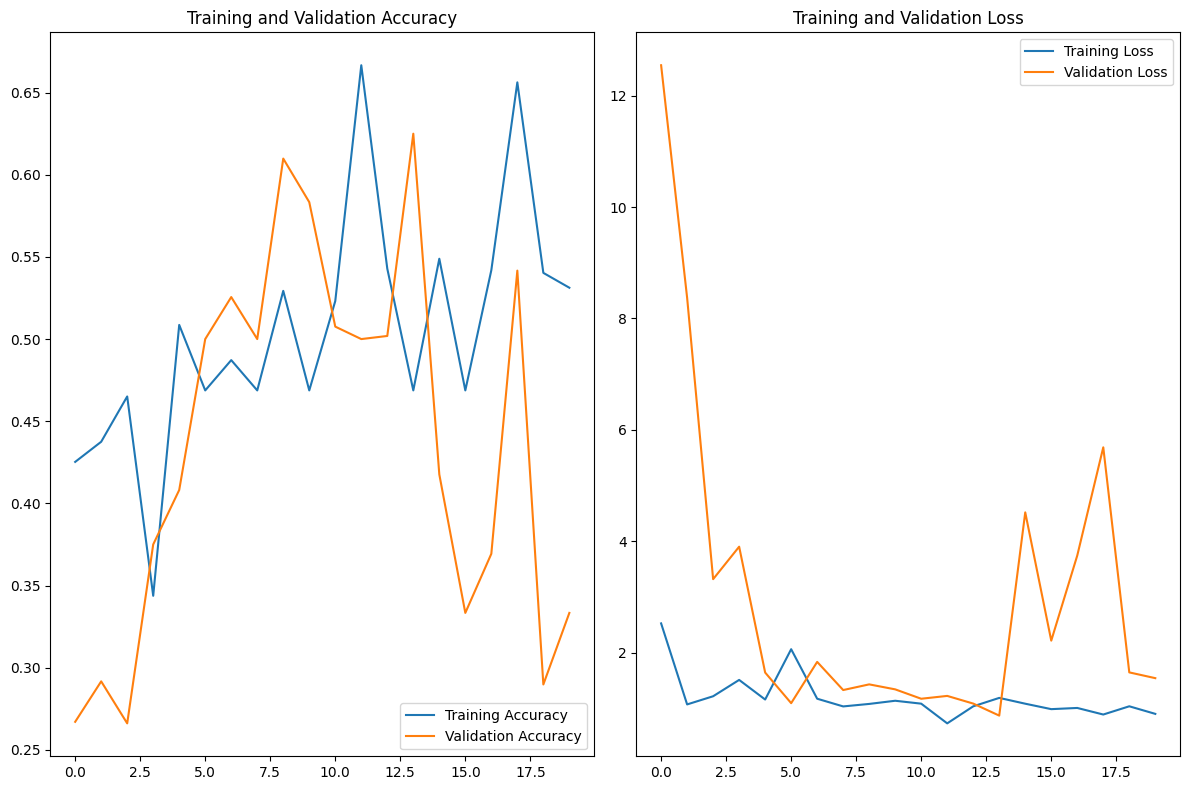

In [23]:
# Train the model


# Plot the training and validation accuracy and loss
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 8))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.tight_layout()
    plt.show()

# Call the function to plot
plot_training_history(history)


In [25]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from keras.layers import Dense, Reshape, Flatten, Conv2D, Conv2DTranspose, LeakyReLU, Dropout, BatchNormalization
from keras.models import Sequential
import numpy as np

def build_generator():
    model = Sequential()

    # Start with a dense layer
    model.add(Dense(7*7*128, activation='relu', input_dim=100))  # Adjust this
    model.add(Reshape((7, 7, 128)))

    # Upsample to reach the required size
    model.add(Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())

    model.add(Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())

    # Adjust to the final output size (224x224x1 for grayscale images)
    model.add(Conv2DTranspose(1, kernel_size=7, strides=4, padding='same', activation='tanh'))

    return model

generator = build_generator()
generator.summary()


# Generator model
def build_generator():
    model = Sequential()

    # Start with a dense layer
    model.add(Dense(7*7*128, activation='relu', input_dim=100))  # Adjust this
    model.add(Reshape((7, 7, 128)))

    # Upsample to reach the required size
    model.add(Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())

    model.add(Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())

    # Adjust to the final output size (224x224x1 for grayscale images)
    model.add(Conv2DTranspose(1, kernel_size=7, strides=4, padding='same', activation='tanh'))

    return model

generator = build_generator()
generator.summary()

# Discriminator model
def build_discriminator(input_shape=(28, 28, 1)):
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, kernel_size=4, strides=2, padding="same", input_shape=input_shape))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Conv2D(128, kernel_size=4, strides=2, padding="same"))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

# GAN model
def build_gan(generator, discriminator):
    discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    discriminator.trainable = False

    gan_input = layers.Input(shape=(100,))
    img = generator(gan_input)
    gan_output = discriminator(img)

    gan = tf.keras.Model(gan_input, gan_output)
    gan.compile(loss='binary_crossentropy', optimizer='adam')

    return gan

# Create models
generator = build_generator()
discriminator = build_discriminator(input_shape=(224, 224, 1))  # Modify for dataset dimensions
gan = build_gan(generator, discriminator)

# Training function
def train_gan(epochs, batch_size, noise_dim, real_data):
    for epoch in range(epochs):
        idx = np.random.randint(0, real_data.shape[0], batch_size)
        real_imgs = real_data[idx]

        noise = np.random.normal(0, 1, (batch_size, noise_dim))
        gen_imgs = generator.predict(noise)

        d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)))
        d_loss_fake = discriminator.train_on_batch(gen_imgs, np.zeros((batch_size, 1)))

        noise = np.random.normal(0, 1, (batch_size, noise_dim))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        if epoch % 100 == 0:
            print(f"Epoch {epoch} - D loss: {d_loss_real[0]}, G loss: {g_loss}")

# After training, discriminator's output can be used to detect anomalies
def detect_anomalies(image):
    score = discriminator.predict(image)
    if score < 0.5:
        return "Anomaly"
    return "Normal"

# Train the GAN
train_gan(epochs=10000, batch_size=32, noise_dim=100, real_data=your_training_data)



NameError: name 'Reshape' is not defined